In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

os.environ["KERAS_BACKEND"] = "torch"
import keras as k
from keras.layers import LSTM, Dense
from keras.models import Sequential

k.backend.backend()

'torch'

In [2]:
df = pd.read_csv("../in/apple_share_price.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,11-Aug-17,156.60,158.57,156.07,157.48,26257096
1,10-Aug-17,159.90,160.00,154.63,155.32,40804273
2,9-Aug-17,159.26,161.27,159.11,161.06,26131530
3,8-Aug-17,158.60,161.83,158.27,160.08,36205896
4,7-Aug-17,157.06,158.92,156.67,158.81,21870321


In [3]:
df.isna().sum()
df.shape

(1664, 6)

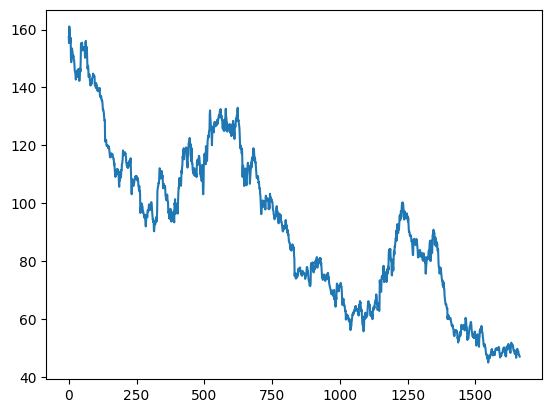

In [4]:
df1 = df.reset_index()["Close"]
df1
plt.plot(df1)

In [5]:
# Normalize the data to ensure that all features have the same scale. This is important for the LSTM to learn effectively.

scaler = MinMaxScaler(feature_range=(0, 1))
df["Close"] = scaler.fit_transform(np.array(df["Close"]).reshape(-1, 1))

Create Sequences for LSTM
Create input sequences for the LSTM model. This involves defining a window of past data that the model will use for prediction.

In [6]:
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        seq = data[i : i + seq_length]
        sequences.append(seq)
    return np.array(sequences)


seq_length = 10  # Adjust as needed
X = create_sequences(df["Close"], seq_length)

In [7]:
# Split Data into Training and Testing Sets:¶

train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
train, test = X[0:train_size], X[train_size : len(X)]

In [9]:
from keras.layers import Dropout

model = Sequential()

# Add the first LSTM layer with return_sequences=True
model.add(LSTM(units=100, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))  # Add dropout for regularization

# Add a second LSTM layer with return_sequences=True
model.add(LSTM(units=100, return_sequences=True))
model.add(Dropout(0.2))

# Add a third LSTM layer with return_sequences=True
model.add(LSTM(units=100, return_sequences=True))
model.add(Dropout(0.2))

# Add a fourth LSTM layer without return_sequences (default is False)
model.add(LSTM(units=100))
model.add(Dropout(0.2))

# Add a Dense layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer="adam", loss="mean_squared_error")

/workspaces/try-ml-stuff/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# LSTM Model Architecture
from keras.utils import plot_model

plot_model(model, to_file="lstm_model.png", show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [11]:
target_data = df["Close"][seq_length : seq_length + train_size]
historyy = model.fit(train, target_data, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.1044 - val_loss: 0.0110
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0072 - val_loss: 0.0018
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0028 - val_loss: 0.0010
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0038 - val_loss: 0.0014
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0029 - val_loss: 9.6066e-04
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0028 - val_loss: 0.0012
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0031 - val_loss: 9.9174e-04
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0027 - val_loss: 9.2246e-04
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0026 - val_loss: 0.0010
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0023 - val_loss: 0.0012


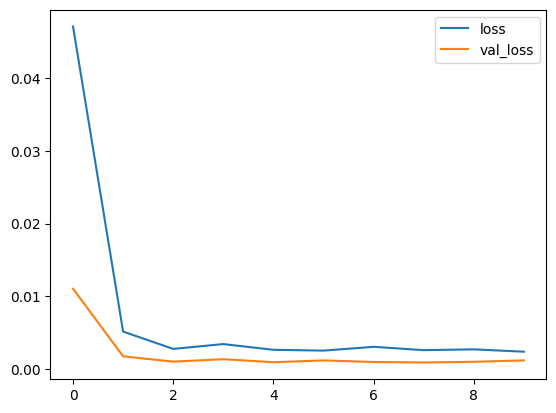

In [12]:
history_df = pd.DataFrame(historyy.history)
history_df.loc[:, ["loss", "val_loss"]].plot();

In [13]:
# Make Predictions
predictions = model.predict(test)
predictions = scaler.inverse_transform(predictions)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


Plot Results

/tmp/ipykernel_19526/3822672195.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Predictions"] = predictions


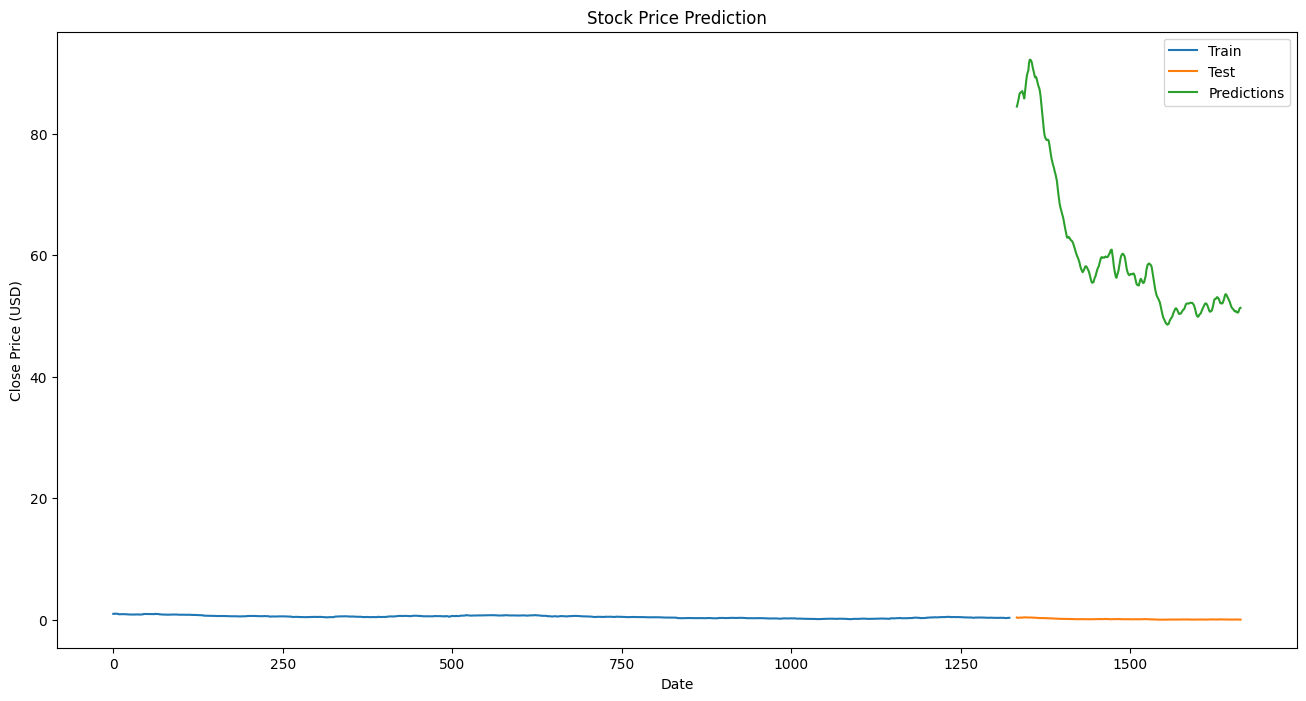

In [14]:
train = df.iloc[:train_size, :]
test = df.iloc[train_size + seq_length :, :]

test["Predictions"] = predictions
plt.figure(figsize=(16, 8))
plt.title("Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.plot(train["Close"])
plt.plot(test[["Close", "Predictions"]])
plt.legend(["Train", "Test", "Predictions"])
plt.show()

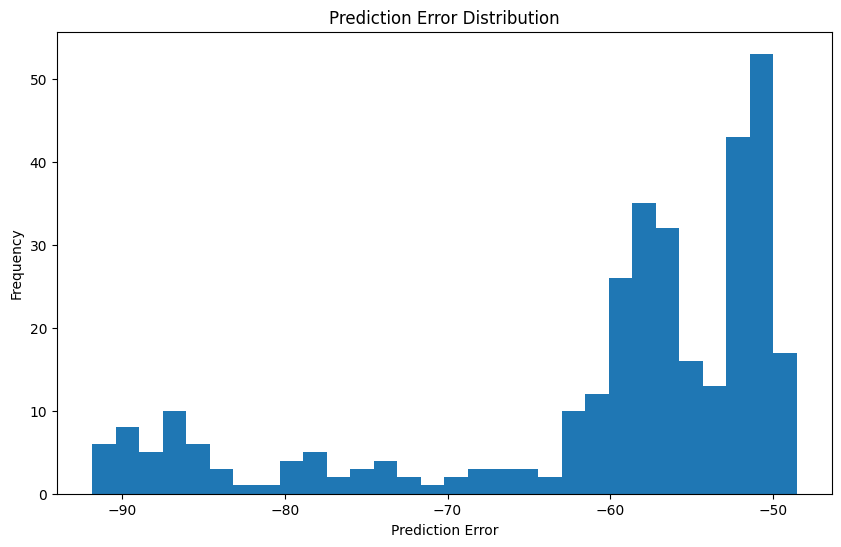

In [15]:
# Prediction Error Distribution
error = test["Close"] - test["Predictions"]
plt.figure(figsize=(10, 6))
plt.hist(error, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

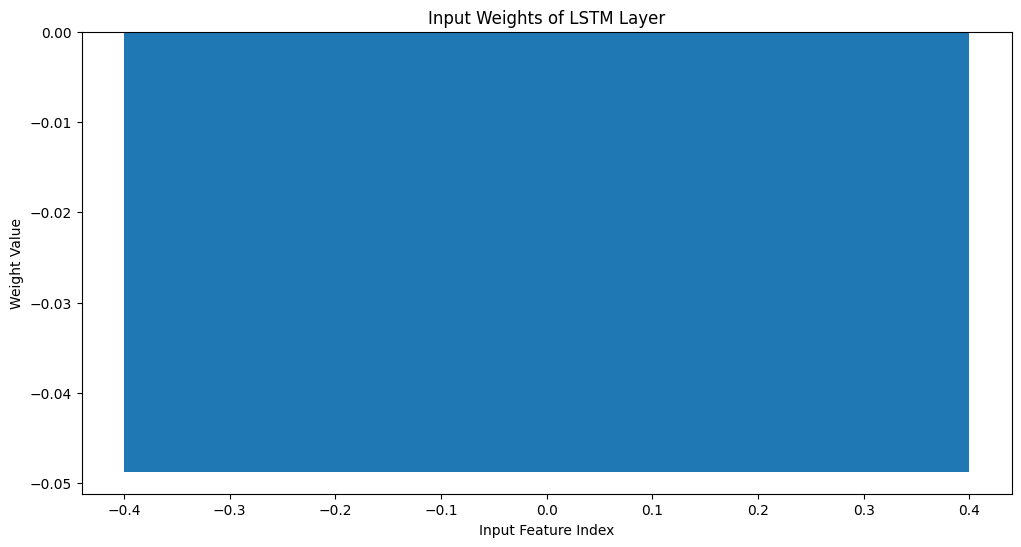

In [16]:
# Feature Importance (Input Weights)
weights = model.layers[0].get_weights()[0]
plt.figure(figsize=(12, 6))
plt.bar(range(len(weights)), weights[:, 0])
plt.title("Input Weights of LSTM Layer")
plt.xlabel("Input Feature Index")
plt.ylabel("Weight Value")
plt.show()

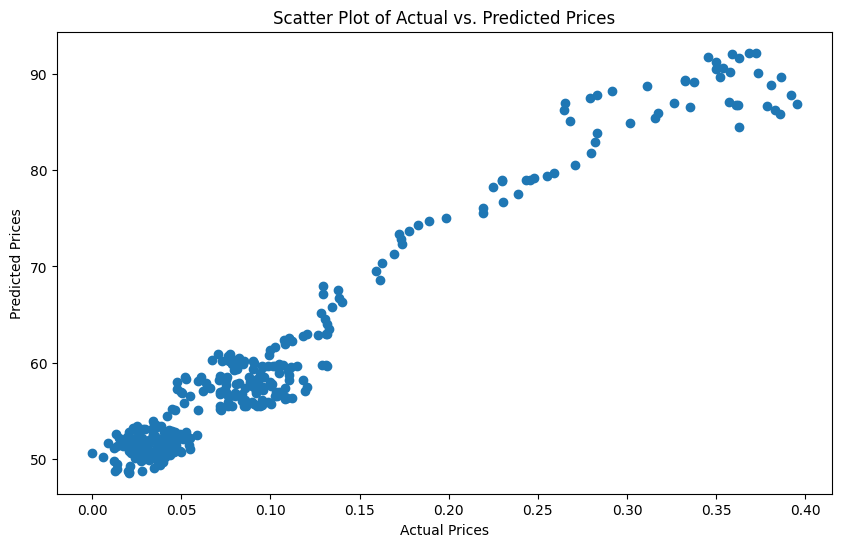

In [17]:
# Scatter Plot of Actual vs. Predicted Prices
plt.figure(figsize=(10, 6))
plt.scatter(test["Close"], test["Predictions"])
plt.title("Scatter Plot of Actual vs. Predicted Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()

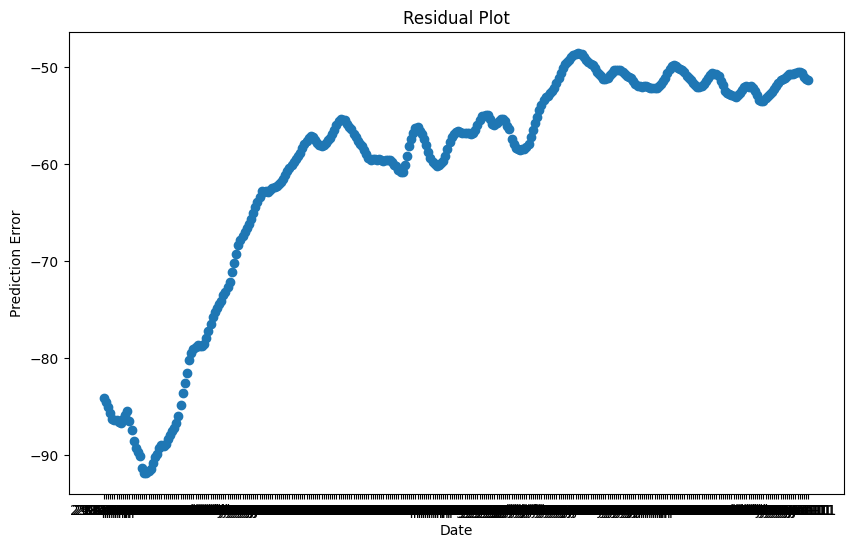

In [18]:
# Residual Plot
plt.figure(figsize=(10, 6))
plt.scatter(test["Date"], error)
plt.title("Residual Plot")
plt.xlabel("Date")
plt.ylabel("Prediction Error")
plt.show()

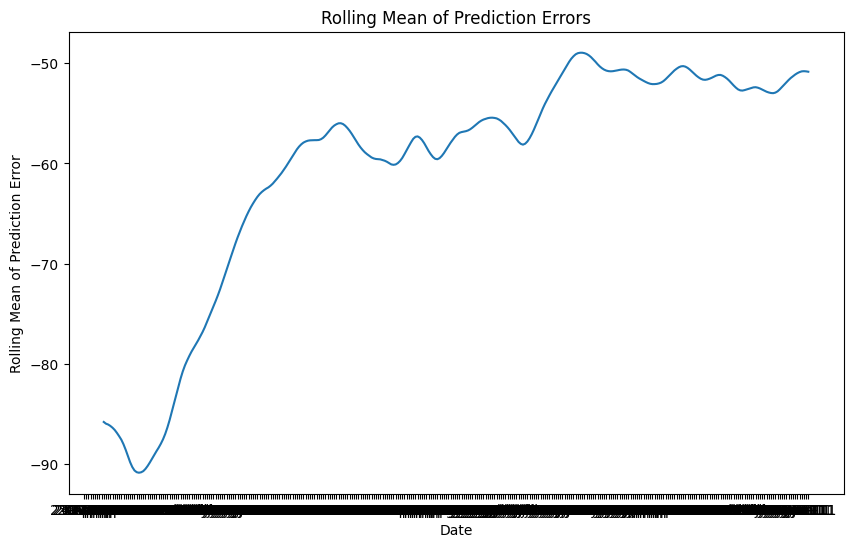

In [19]:
# Rolling Mean of Prediction Errors
rolling_mean = error.rolling(window=10).mean()
plt.figure(figsize=(10, 6))
plt.plot(test["Date"], rolling_mean)
plt.title("Rolling Mean of Prediction Errors")
plt.xlabel("Date")
plt.ylabel("Rolling Mean of Prediction Error")
plt.show()

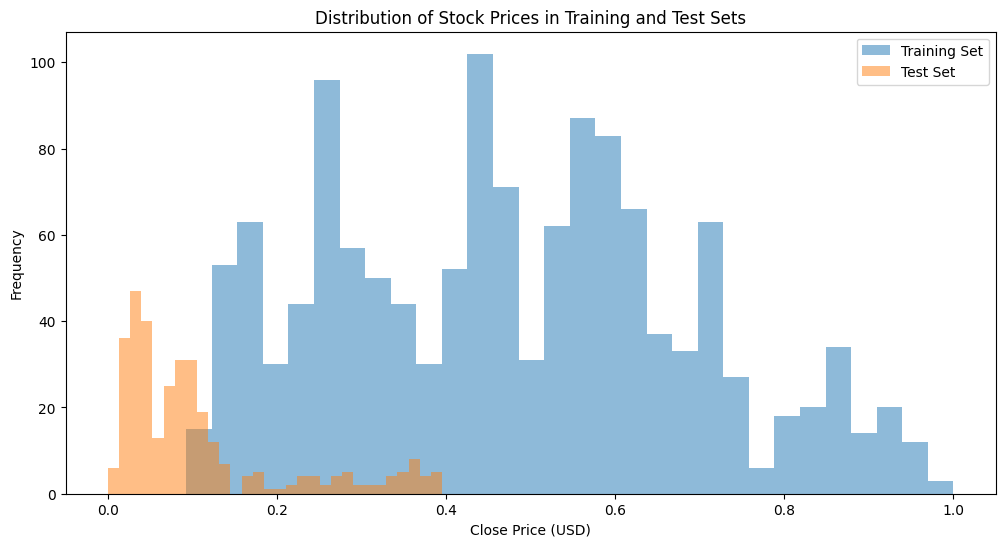

In [20]:
# Distribution of Training and Test Sets
plt.figure(figsize=(12, 6))
plt.hist(train["Close"], bins=30, alpha=0.5, label="Training Set")
plt.hist(test["Close"], bins=30, alpha=0.5, label="Test Set")
plt.title("Distribution of Stock Prices in Training and Test Sets")
plt.xlabel("Close Price (USD)")
plt.ylabel("Frequency")
plt.legend()
plt.show()